In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Priya/Desktop/Factory-Reallocation-Optimization/data/prepared_data.csv")

In [2]:
print(df.shape)
df.head()
df.info()
df.describe()

(8928, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Row ID                  8928 non-null   int64  
 1   Order ID                8928 non-null   object 
 2   Order Date              8928 non-null   object 
 3   Ship Date               8928 non-null   object 
 4   Ship Mode               8928 non-null   object 
 5   Customer ID             8928 non-null   int64  
 6   Country/Region          8928 non-null   object 
 7   City                    8928 non-null   object 
 8   State/Province          8928 non-null   object 
 9   Postal Code             8928 non-null   int64  
 10  Division                8928 non-null   object 
 11  Region                  8928 non-null   object 
 12  Product ID              8928 non-null   object 
 13  Product Name            8928 non-null   object 
 14  Sales                   8928 

,Row ID,Customer ID,Postal Code,Sales,Units,Gross Profit,Cost,Lead Time,Profit Margin,Factory Latitude,Factory Longitude,Customer Latitude,Customer Longitude,Shipping Distance (km)
count,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000
mean,5077.068772,134575.470318,60446.615143,13.914808,3.793459,9.174703,4.740105,1319.681564,0.665482,32.797229,-98.517508,37.449814,-96.739486,1943.179438
std,2945.274626,20124.979059,29734.098135,11.411068,2.218418,6.663524,5.105163,263.363219,0.066186,1.583871,14.974519,5.025351,17.637521,1088.710815
min,1.000000,100013.000000,1040.000000,1.250000,1.000000,0.250000,0.600000,904.000000,0.076923,32.076176,-111.768036,25.466500,-123.117400,1.071762
25%,2513.500000,117422.000000,33024.000000,7.200000,2.000000,4.980000,2.400000,1271.000000,0.653333,32.076176,-111.768036,33.953300,-118.139000,1032.378759
50%,5093.500000,133711.000000,62521.000000,10.800000,3.000000,7.470000,3.600000,1274.000000,0.666667,32.881893,-111.768036,37.755800,-93.211100,1649.497940
75%,7625.250000,152129.750000,90036.000000,18.000000,5.000000,12.250000,5.700000,1637.000000,0.694444,32.881893,-81.088371,40.914700,-81.728600,2897.263115
max,10192.000000,169978.000000,99301.000000,260.000000,14.000000,130.000000,130.000000,1642.000000,0.800000,48.119140,-81.088371,48.754800,-68.790600,3899.536837


In [3]:
missing = df.isnull().sum()

missing

Row ID                    0
Order ID                  0
Order Date                0
Ship Date                 0
Ship Mode                 0
Customer ID               0
Country/Region            0
City                      0
State/Province            0
Postal Code               0
Division                  0
Region                    0
Product ID                0
Product Name              0
Sales                     0
Units                     0
Gross Profit              0
Cost                      0
Lead Time                 0
Profit Margin             0
Factory                   0
Factory Latitude          0
Factory Longitude         0
Customer Latitude         0
Customer Longitude        0
Shipping Distance (km)    0
dtype: int64

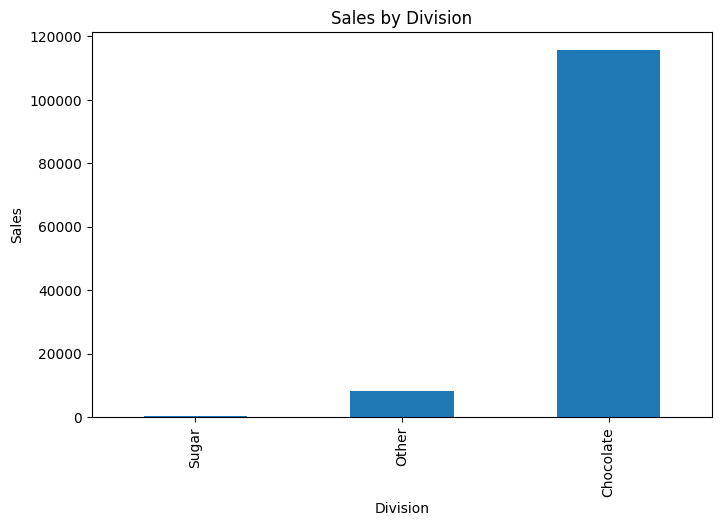

In [4]:
sales_division = df.groupby("Division")["Sales"].sum().sort_values()

sales_division.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Division")
plt.ylabel("Sales")
plt.show()

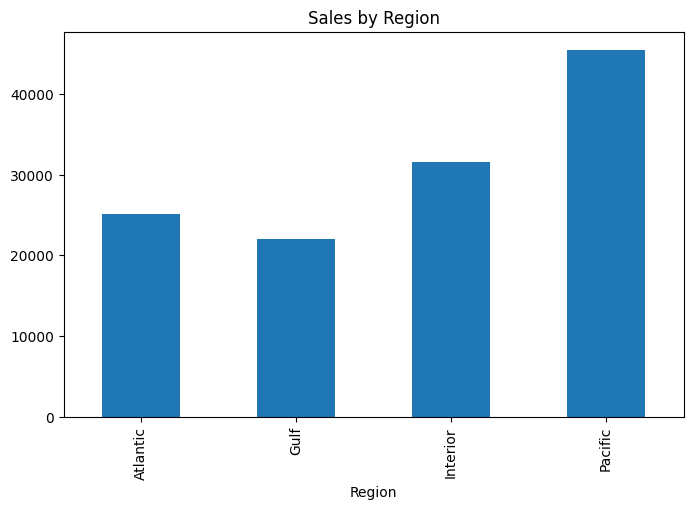

In [5]:
sales_region = df.groupby("Region")["Sales"].sum()

sales_region.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.show()

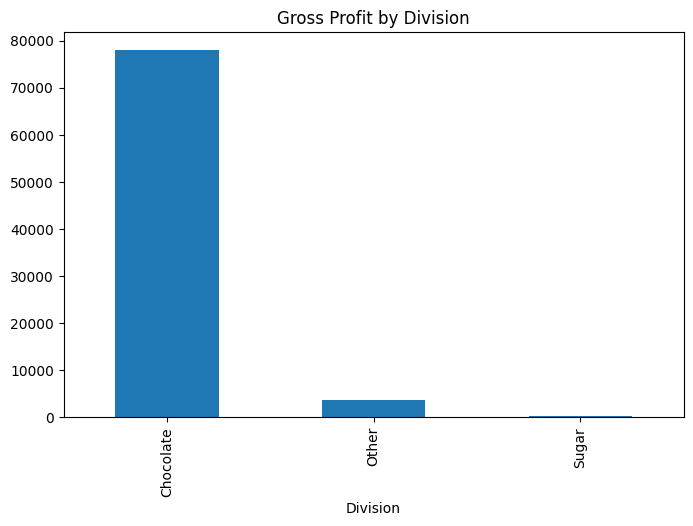

In [6]:
profit = df.groupby("Division")["Gross Profit"].sum()

profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Gross Profit by Division")
plt.show()

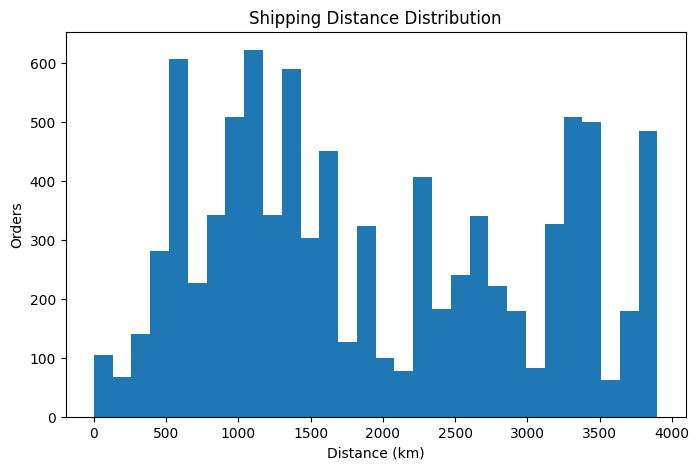

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Shipping Distance (km)"],
    bins=30
)

plt.title("Shipping Distance Distribution")

plt.xlabel("Distance (km)")

plt.ylabel("Orders")

plt.show()

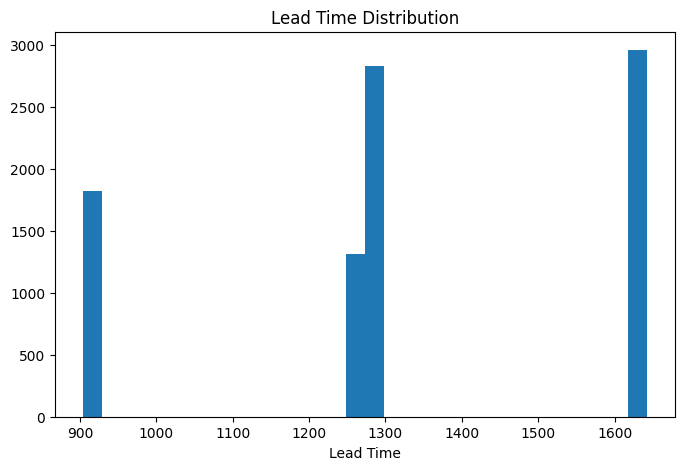

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Lead Time"],
    bins=30
)

plt.title("Lead Time Distribution")

plt.xlabel("Lead Time")

plt.show()

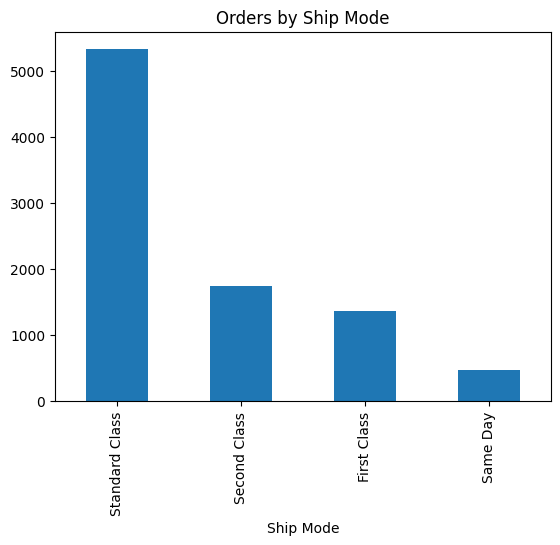

In [9]:
df["Ship Mode"].value_counts().plot(
    kind="bar"
)

plt.title("Orders by Ship Mode")

plt.show()

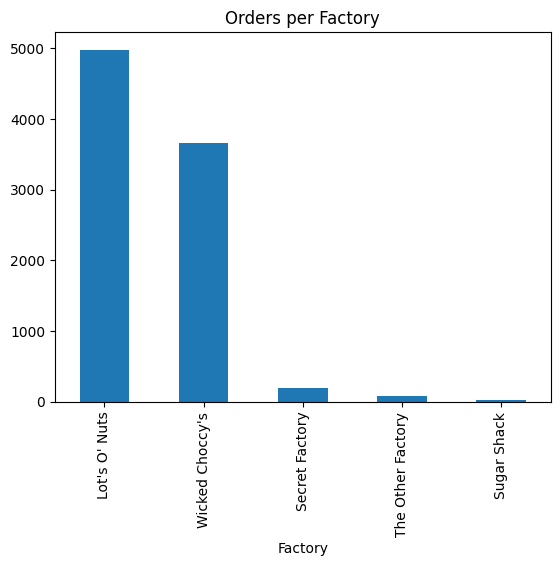

In [10]:
df["Factory"].value_counts().plot(
    kind="bar"
)

plt.title("Orders per Factory")

plt.show()

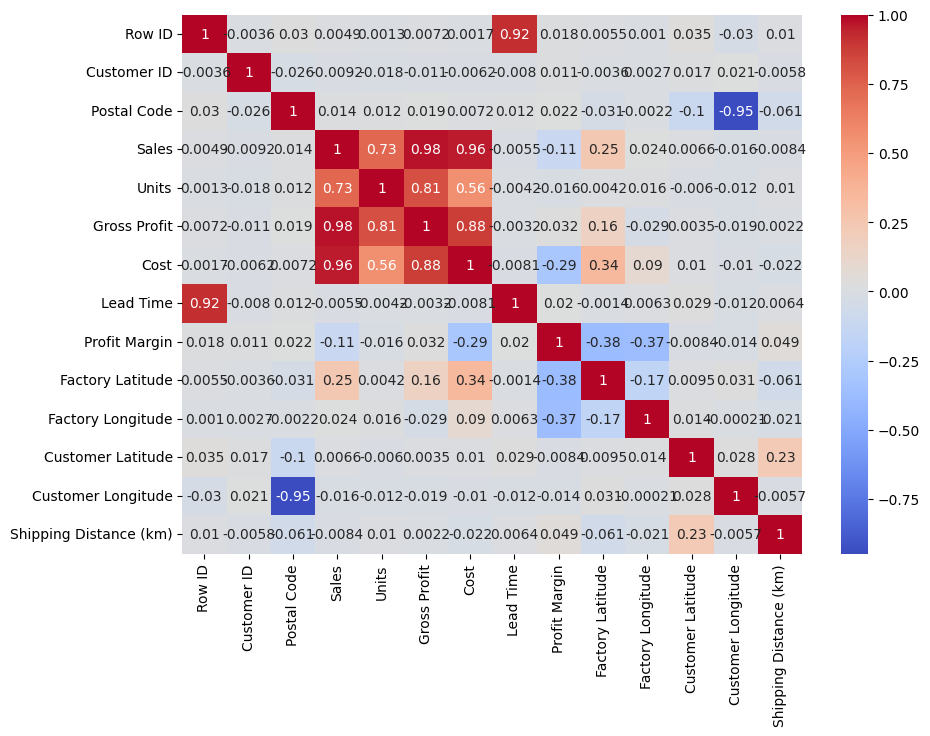

In [11]:
import numpy as np

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

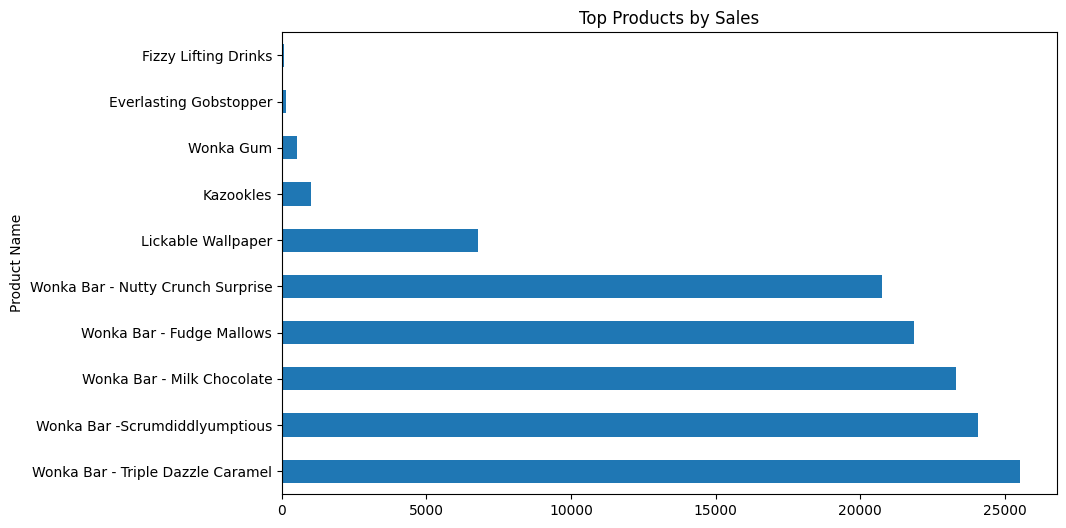

In [12]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Products by Sales")

plt.show()

In [13]:
print("Total Orders :", len(df))

print("Total Sales :", round(df["Sales"].sum(),2))

print("Total Profit :", round(df["Gross Profit"].sum(),2))

print("Average Lead Time :", round(df["Lead Time"].mean(),2))

print("Average Shipping Distance :", round(df["Shipping Distance (km)"].mean(),2))

Total Orders : 8928
Total Sales : 124231.41
Total Profit : 81911.75
Average Lead Time : 1319.68
Average Shipping Distance : 1943.18
